# ✅롤(League Of Legend) 데이터 분석

# 데이터 셋 준비

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## pandas 로 csv 파일 읽기

In [2]:
base_path = r'/content/drive/MyDrive/KoreaIT (코리아it)/250107 💚자연어처리/[AI자연어]/dataset(AI2501)'

In [3]:
file_name = r'high_diamond_ranked_10min.csv'

In [4]:
file_path = os.path.join(base_path, file_name)
df = pd.read_csv(file_path)
df

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,...,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,...,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,...,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,...,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,...,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9874,4527873286,1,17,2,1,7,4,5,1,1,...,0,15246,6.8,16498,229,34,-2519,-2469,22.9,1524.6
9875,4527797466,1,54,0,0,6,4,8,1,1,...,0,15456,7.0,18367,206,56,-782,-888,20.6,1545.6
9876,4527713716,0,23,1,0,6,7,5,0,0,...,0,18319,7.4,19909,261,60,2416,1877,26.1,1831.9
9877,4527628313,0,14,4,1,2,3,3,1,1,...,0,15298,7.2,18314,247,40,839,1085,24.7,1529.8


## 데이터 소개
- 이번 주제는 League of Legends Diamond Ranked Games (10 min) 데이터셋을 사용합니다.

    
- 다음 1개의 csv 파일을 사용합니다.
    - high_diamond_ranked_10min.csv
    
    
- 각 파일의 컬럼은 아래와 같습니다.
    - gameId: 게임 판의 고유 ID
    - **blueWins**: 블루팀의 승리 여부 (0: 패배, 1: 승리)  <-- ⭐타겟값
    - xxxWardsPlaced: xxx팀에서 설치한 와드의 수
    - xxxWardsDestroyed: xxx팀에서 파괴한 와드의 수
    - xxxFirstBlood: xxx팀의 첫번째 킬 달성 여부
    - xxxKills: xxx팀의 킬 수
    - xxxDeaths: xxx팀의 죽음 수
    - xxxAssists: xxx팀의 어시스트 수
    - xxxEliteMonsters: xxx팀이 죽인 엘리트 몬스터 수
    - xxxDragons: xxx팀이 죽인 용의 수
    - xxxHeralds: xxx팀이 죽인 전령의 수
    - xxxTowersDestroyed: xxx팀이 파괴한 탑의 수
    - xxxTotalGold: xxx팀의 전체 획득 골드
    - xxxAvgLevel: xxx팀의 평균 레벨
    - xxxTotalExperience: xxx팀의 총 경험치 획득량
    - xxxTotalMinionsKilled: xxx팀의 총 미니언 킬 수
    - xxxTotalJungleMinionsKilled: xxx팀의 총 정글 미니언 킬 수
    - xxxGoldDiff: xxx팀과 다른 팀 간의 골드 획득량 차이
    - xxxExperienceDiff: xxx팀과 다른 팀과의 경험치 획득량 차이
    - xxxCSPerMin: xxx팀의 분당 CS 스코어
    - xxxGoldPerMin: xxx팀의 분당 골드 획득량
      
        
- 데이터 출처: https://www.kaggle.com/bobbyscience/league-of-legends-diamond-ranked-games-10-min

# EDA, 기초 통계 분석

In [5]:
df.head()

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,...,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,...,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,...,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,...,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,...,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4


In [6]:
df.columns

Index(['gameId', 'blueWins', 'blueWardsPlaced', 'blueWardsDestroyed',
       'blueFirstBlood', 'blueKills', 'blueDeaths', 'blueAssists',
       'blueEliteMonsters', 'blueDragons', 'blueHeralds',
       'blueTowersDestroyed', 'blueTotalGold', 'blueAvgLevel',
       'blueTotalExperience', 'blueTotalMinionsKilled',
       'blueTotalJungleMinionsKilled', 'blueGoldDiff', 'blueExperienceDiff',
       'blueCSPerMin', 'blueGoldPerMin', 'redWardsPlaced', 'redWardsDestroyed',
       'redFirstBlood', 'redKills', 'redDeaths', 'redAssists',
       'redEliteMonsters', 'redDragons', 'redHeralds', 'redTowersDestroyed',
       'redTotalGold', 'redAvgLevel', 'redTotalExperience',
       'redTotalMinionsKilled', 'redTotalJungleMinionsKilled', 'redGoldDiff',
       'redExperienceDiff', 'redCSPerMin', 'redGoldPerMin'],
      dtype='object')

In [7]:
df[['blueGoldDiff', 'redGoldDiff']]

,blueGoldDiff,redGoldDiff
0,643,-643
1,-2908,2908
2,-1172,1172
3,-1321,1321
4,-1004,1004
...,...,...
9874,2519,-2519
9875,782,-782
9876,-2416,2416
9877,-839,839


In [8]:
df[['blueAvgLevel']]

,blueAvgLevel
0,6.6
1,6.6
2,6.4
3,7.0
4,7.0
...,...
9874,7.2
9875,7.2
9876,7.0
9877,6.6


In [9]:
df[['blueAvgLevel']].max()

,0
blueAvgLevel,8.0


In [10]:
# bludGoldDiff :
#     아마 regGoldDiff 와 부호가 다른 관계에 있을듯.  즉 중복된 정보일 가능성이 크다.
#     이 경우 한가지만 사용해도 될것이다.
#     multi-core linearity 를 가지는 값들은 drop 해서 제거할 필요가 있어 보인다.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gameId                        9879 non-null   int64  
 1   blueWins                      9879 non-null   int64  
 2   blueWardsPlaced               9879 non-null   int64  
 3   blueWardsDestroyed            9879 non-null   int64  
 4   blueFirstBlood                9879 non-null   int64  
 5   blueKills                     9879 non-null   int64  
 6   blueDeaths                    9879 non-null   int64  
 7   blueAssists                   9879 non-null   int64  
 8   blueEliteMonsters             9879 non-null   int64  
 9   blueDragons                   9879 non-null   int64  
 10  blueHeralds                   9879 non-null   int64  
 11  blueTowersDestroyed           9879 non-null   int64  
 12  blueTotalGold                 9879 non-null   int64  
 13  blu

In [12]:
df.describe()

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
count,9.879000e+03,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,...,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000
mean,4.500084e+09,0.499038,22.288288,2.824881,0.504808,6.183925,6.137666,6.645106,0.549954,0.361980,...,0.043021,16489.041401,6.925316,17961.730438,217.349226,51.313088,-14.414111,33.620306,21.734923,1648.904140
std,2.757328e+07,0.500024,18.019177,2.174998,0.500002,3.011028,2.933818,4.064520,0.625527,0.480597,...,0.216900,1490.888406,0.305311,1198.583912,21.911668,10.027885,2453.349179,1920.370438,2.191167,149.088841
min,4.295358e+09,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,11212.000000,4.800000,10465.000000,107.000000,4.000000,-11467.000000,-8348.000000,10.700000,1121.200000
25%,4.483301e+09,0.000000,14.000000,1.000000,0.000000,4.000000,4.000000,4.000000,0.000000,0.000000,...,0.000000,15427.500000,6.800000,17209.500000,203.000000,44.000000,-1596.000000,-1212.000000,20.300000,1542.750000
50%,4.510920e+09,0.000000,16.000000,3.000000,1.000000,6.000000,6.000000,6.000000,0.000000,0.000000,...,0.000000,16378.000000,7.000000,17974.000000,218.000000,51.000000,-14.000000,28.000000,21.800000,1637.800000
75%,4.521733e+09,1.000000,20.000000,4.000000,1.000000,8.000000,8.000000,9.000000,1.000000,1.000000,...,0.000000,17418.500000,7.200000,18764.500000,233.000000,57.000000,1585.500000,1290.500000,23.300000,1741.850000
max,4.527991e+09,1.000000,250.000000,27.000000,1.000000,22.000000,22.000000,29.000000,2.000000,1.000000,...,2.000000,22732.000000,8.200000,22269.000000,289.000000,92.000000,10830.000000,9333.000000,28.900000,2273.200000


In [13]:
df.describe()[['blueDragons', 'redDragons']]

,blueDragons,redDragons
count,9879.000000,9879.000000
mean,0.361980,0.413098
std,0.480597,0.492415
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,1.000000
max,1.000000,1.000000


## 각 컬럼의 corr 을 히트맵으로 시각화

In [14]:
df.corr()

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
gameId,1.000000,0.000985,0.005361,-0.012057,-0.011577,-0.038993,-0.013160,-0.023329,0.016599,0.008962,...,0.003557,-0.010622,-0.012419,-0.021187,-0.005118,0.006040,0.014670,0.012315,-0.005118,-0.010622
blueWins,0.000985,1.000000,0.000087,0.044247,0.201769,0.337358,-0.339297,0.276685,0.221944,0.213768,...,-0.103696,-0.411396,-0.352127,-0.387588,-0.212171,-0.110994,-0.511119,-0.489558,-0.212171,-0.411396
blueWardsPlaced,0.005361,0.000087,1.000000,0.034447,0.003228,0.018138,-0.002612,0.033217,0.019892,0.017676,...,-0.008225,-0.005685,-0.008882,-0.013000,-0.012395,0.001224,-0.015800,-0.027943,-0.012395,-0.005685
blueWardsDestroyed,-0.012057,0.044247,0.034447,1.000000,0.017717,0.033748,-0.073182,0.067793,0.041700,0.040504,...,-0.023943,-0.067467,-0.059090,-0.057314,0.040023,-0.035732,-0.078585,-0.077946,0.040023,-0.067467
blueFirstBlood,-0.011577,0.201769,0.003228,0.017717,1.000000,0.269425,-0.247929,0.229485,0.151603,0.134309,...,-0.069584,-0.301479,-0.182602,-0.194920,-0.156711,-0.024559,-0.378511,-0.240665,-0.156711,-0.301479
blueKills,-0.038993,0.337358,0.018138,0.033748,0.269425,1.000000,0.004044,0.813667,0.178540,0.170436,...,-0.082491,-0.161127,-0.412219,-0.462333,-0.472203,-0.214454,-0.654148,-0.583730,-0.472203,-0.161127
blueDeaths,-0.013160,-0.339297,-0.002612,-0.073182,-0.247929,0.004044,1.000000,-0.026372,-0.204764,-0.188852,...,0.156780,0.885728,0.433383,0.464584,-0.040521,-0.100271,0.640000,0.577613,-0.040521,0.885728
blueAssists,-0.023329,0.276685,0.033217,0.067793,0.229485,0.813667,-0.026372,1.000000,0.149043,0.170873,...,-0.060880,-0.133948,-0.356928,-0.396652,-0.337515,-0.160915,-0.549761,-0.437002,-0.337515,-0.133948
blueEliteMonsters,0.016599,0.221944,0.019892,0.041700,0.151603,0.178540,-0.204764,0.149043,1.000000,0.781039,...,-0.052029,-0.216616,-0.169649,-0.189816,-0.074838,-0.087893,-0.281464,-0.263991,-0.074838,-0.216616
blueDragons,0.008962,0.213768,0.017676,0.040504,0.134309,0.170436,-0.188852,0.170873,0.781039,1.000000,...,-0.032865,-0.192871,-0.149806,-0.159485,-0.059803,-0.098446,-0.233875,-0.211496,-0.059803,-0.192871


<Axes: >

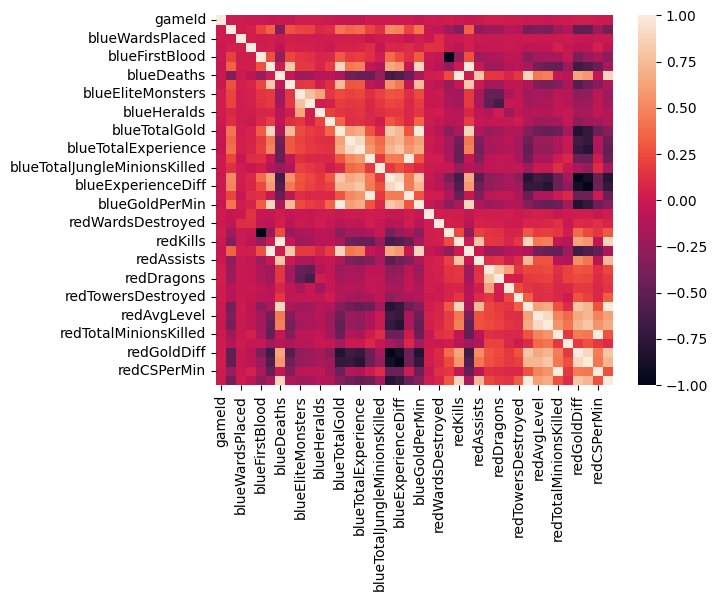

In [15]:
sns.heatmap(df.corr())

<Axes: >

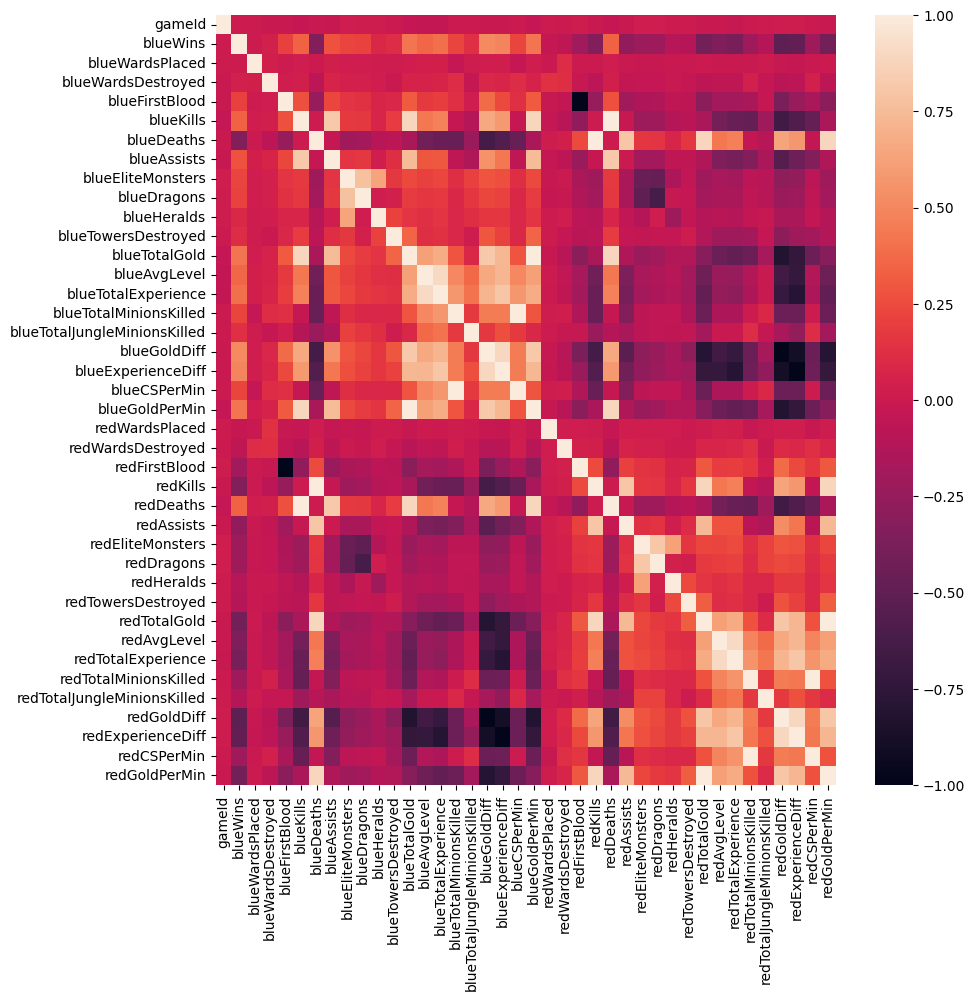

In [16]:
fig = plt.figure(figsize=(10, 10))
sns.heatmap(df.corr())

<Axes: >

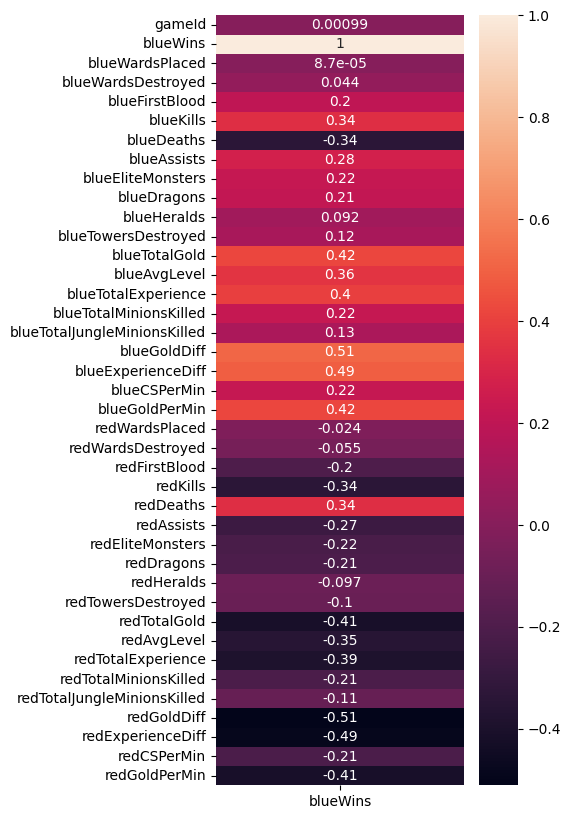

In [17]:
fig = plt.figure(figsize=(4, 10))
sns.heatmap(df.corr()[['blueWins']], annot=True)

In [18]:
df.corr()

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
gameId,1.000000,0.000985,0.005361,-0.012057,-0.011577,-0.038993,-0.013160,-0.023329,0.016599,0.008962,...,0.003557,-0.010622,-0.012419,-0.021187,-0.005118,0.006040,0.014670,0.012315,-0.005118,-0.010622
blueWins,0.000985,1.000000,0.000087,0.044247,0.201769,0.337358,-0.339297,0.276685,0.221944,0.213768,...,-0.103696,-0.411396,-0.352127,-0.387588,-0.212171,-0.110994,-0.511119,-0.489558,-0.212171,-0.411396
blueWardsPlaced,0.005361,0.000087,1.000000,0.034447,0.003228,0.018138,-0.002612,0.033217,0.019892,0.017676,...,-0.008225,-0.005685,-0.008882,-0.013000,-0.012395,0.001224,-0.015800,-0.027943,-0.012395,-0.005685
blueWardsDestroyed,-0.012057,0.044247,0.034447,1.000000,0.017717,0.033748,-0.073182,0.067793,0.041700,0.040504,...,-0.023943,-0.067467,-0.059090,-0.057314,0.040023,-0.035732,-0.078585,-0.077946,0.040023,-0.067467
blueFirstBlood,-0.011577,0.201769,0.003228,0.017717,1.000000,0.269425,-0.247929,0.229485,0.151603,0.134309,...,-0.069584,-0.301479,-0.182602,-0.194920,-0.156711,-0.024559,-0.378511,-0.240665,-0.156711,-0.301479
blueKills,-0.038993,0.337358,0.018138,0.033748,0.269425,1.000000,0.004044,0.813667,0.178540,0.170436,...,-0.082491,-0.161127,-0.412219,-0.462333,-0.472203,-0.214454,-0.654148,-0.583730,-0.472203,-0.161127
blueDeaths,-0.013160,-0.339297,-0.002612,-0.073182,-0.247929,0.004044,1.000000,-0.026372,-0.204764,-0.188852,...,0.156780,0.885728,0.433383,0.464584,-0.040521,-0.100271,0.640000,0.577613,-0.040521,0.885728
blueAssists,-0.023329,0.276685,0.033217,0.067793,0.229485,0.813667,-0.026372,1.000000,0.149043,0.170873,...,-0.060880,-0.133948,-0.356928,-0.396652,-0.337515,-0.160915,-0.549761,-0.437002,-0.337515,-0.133948
blueEliteMonsters,0.016599,0.221944,0.019892,0.041700,0.151603,0.178540,-0.204764,0.149043,1.000000,0.781039,...,-0.052029,-0.216616,-0.169649,-0.189816,-0.074838,-0.087893,-0.281464,-0.263991,-0.074838,-0.216616
blueDragons,0.008962,0.213768,0.017676,0.040504,0.134309,0.170436,-0.188852,0.170873,0.781039,1.000000,...,-0.032865,-0.192871,-0.149806,-0.159485,-0.059803,-0.098446,-0.233875,-0.211496,-0.059803,-0.192871


### multi-colinearity 문제

In [19]:
"""
↑ [관찰]
 + 혹은 - 로 나타나는 관계가 있다

   blueKills 와 redKills
   blueDeaths 와 redDeaths


즉, 정확히 반대로 나타나는 데이터들
이 상태에서 LinearRegression 이나 LogisticRegression 을 하게 되면
multi-collinearity 가 발생할수 있다.

즉 blueKills 와 redKills 과 음/양 완전히 반대인 상태에서 학습이 양쪽 방향으로 진행되면서
원하는 대로의 학습이 진행되지 않는 문제들이 발생할수 있다.

이런 경우 multi-colinearity 를 배제하여 훈련시킬 필요가 있다.

"""
None

# 각 컬럼의 승리여부 관계 분석

## 수치형 데이터 분석

In [20]:
df.columns

Index(['gameId', 'blueWins', 'blueWardsPlaced', 'blueWardsDestroyed',
       'blueFirstBlood', 'blueKills', 'blueDeaths', 'blueAssists',
       'blueEliteMonsters', 'blueDragons', 'blueHeralds',
       'blueTowersDestroyed', 'blueTotalGold', 'blueAvgLevel',
       'blueTotalExperience', 'blueTotalMinionsKilled',
       'blueTotalJungleMinionsKilled', 'blueGoldDiff', 'blueExperienceDiff',
       'blueCSPerMin', 'blueGoldPerMin', 'redWardsPlaced', 'redWardsDestroyed',
       'redFirstBlood', 'redKills', 'redDeaths', 'redAssists',
       'redEliteMonsters', 'redDragons', 'redHeralds', 'redTowersDestroyed',
       'redTotalGold', 'redAvgLevel', 'redTotalExperience',
       'redTotalMinionsKilled', 'redTotalJungleMinionsKilled', 'redGoldDiff',
       'redExperienceDiff', 'redCSPerMin', 'redGoldPerMin'],
      dtype='object')

<Axes: xlabel='blueGoldDiff', ylabel='Count'>

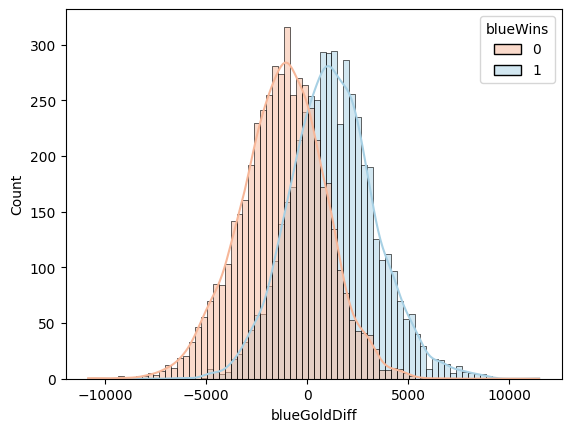

In [21]:
sns.histplot(data=df, x='blueGoldDiff', hue='blueWins', palette='RdBu', kde=True)

<Axes: xlabel='blueKills', ylabel='Count'>

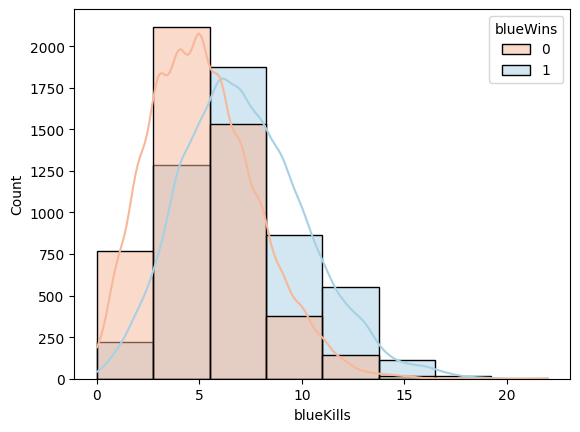

In [22]:
sns.histplot(data=df, x='blueKills', hue='blueWins', palette='RdBu', kde=True, bins=8)

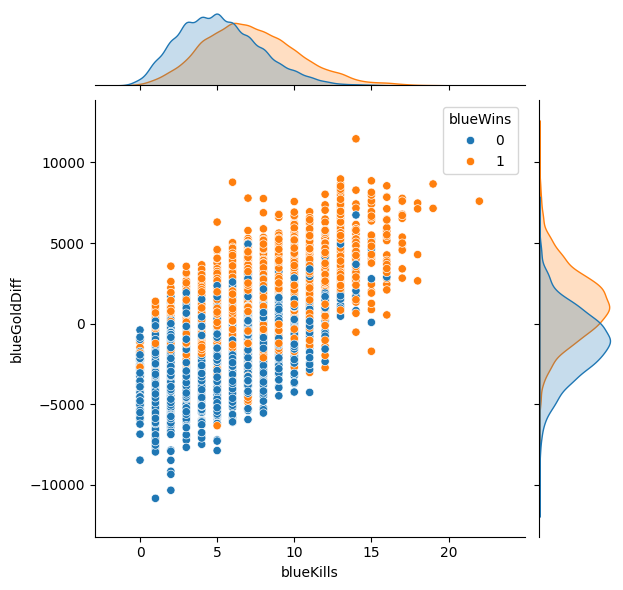

In [23]:
sns.jointplot(data=df, x='blueKills', y='blueGoldDiff', hue='blueWins')

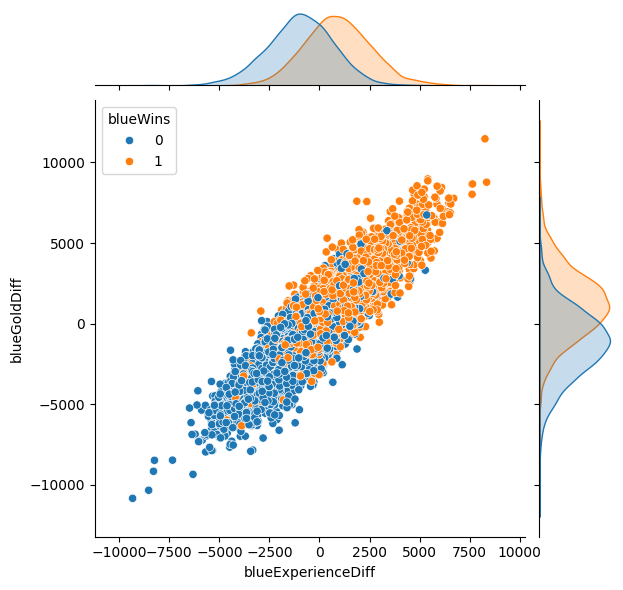

In [24]:
sns.jointplot(data=df, x='blueExperienceDiff', y='blueGoldDiff', hue='blueWins')

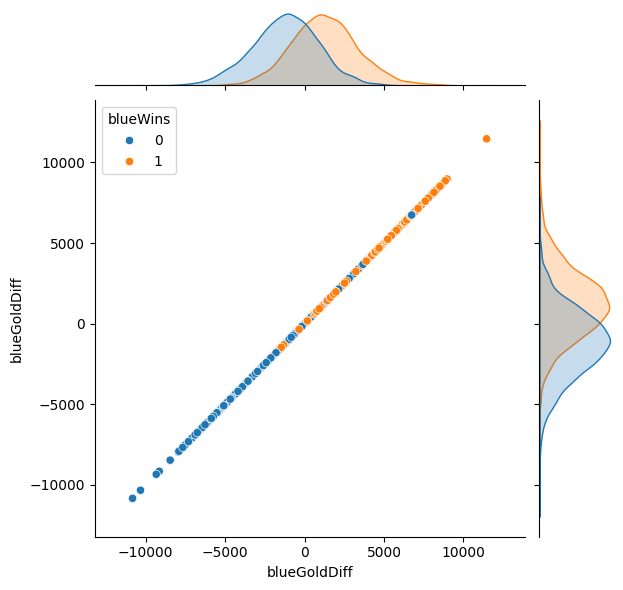

In [25]:
sns.jointplot(data=df, x='blueGoldDiff', y='blueGoldDiff', hue='blueWins')

## 분류형 데이터 분석

In [26]:
df.blueDragons.value_counts()

,count
blueDragons,
0,6303
1,3576


<Axes: xlabel='blueDragons', ylabel='count'>

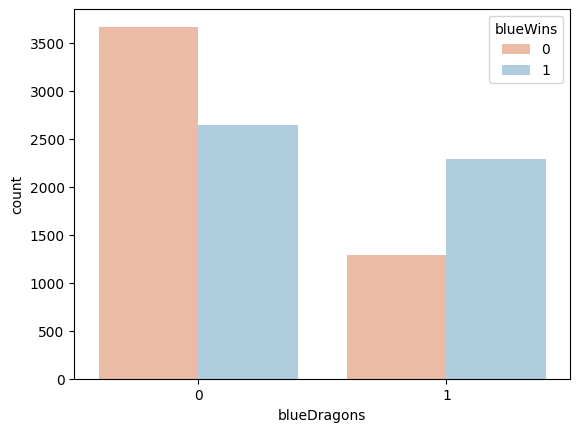

In [27]:
sns.countplot(data=df, x='blueDragons', hue='blueWins', palette='RdBu')

<Axes: xlabel='redDragons', ylabel='count'>

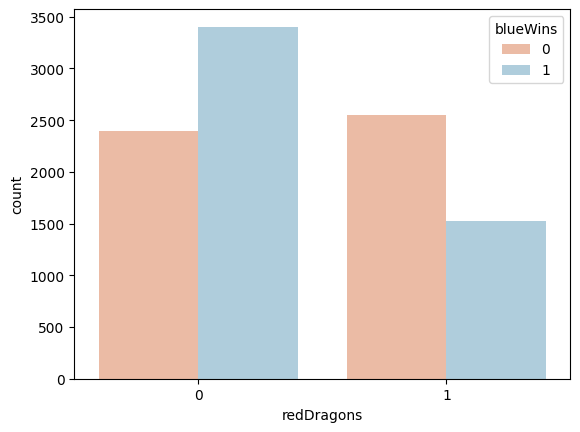

In [28]:
sns.countplot(data=df, x='redDragons', hue='blueWins', palette='RdBu')

<Axes: xlabel='blueFirstBlood', ylabel='count'>

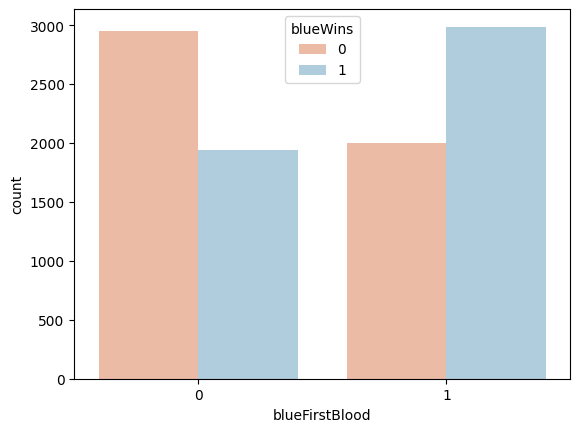

In [29]:
sns.countplot(data=df, x='blueFirstBlood', hue='blueWins', palette='RdBu')

# 모델 학습을 위한 데이터 전처리

## 학습에 불필요한 컬럼을 제거 .
- **df** 에서 다음의 불필요한 컬럼들을 제거합니다
>'gameId', 'redFirstBlood', 'redKills', 'redDeaths','redTotalGold', 'redTotalExperience', 'redGoldDiff','redExperienceDiff'

- 컬럼이 제거된 df 의 df.head() 출력 하기
- 컬럼이 제거된 df 의 column 개수 출력 하기

In [36]:
df.columns

Index(['gameId', 'blueWins', 'blueWardsPlaced', 'blueWardsDestroyed',
       'blueFirstBlood', 'blueKills', 'blueDeaths', 'blueAssists',
       'blueEliteMonsters', 'blueDragons', 'blueHeralds',
       'blueTowersDestroyed', 'blueTotalGold', 'blueAvgLevel',
       'blueTotalExperience', 'blueTotalMinionsKilled',
       'blueTotalJungleMinionsKilled', 'blueGoldDiff', 'blueExperienceDiff',
       'blueCSPerMin', 'blueGoldPerMin', 'redWardsPlaced', 'redWardsDestroyed',
       'redFirstBlood', 'redKills', 'redDeaths', 'redAssists',
       'redEliteMonsters', 'redDragons', 'redHeralds', 'redTowersDestroyed',
       'redTotalGold', 'redAvgLevel', 'redTotalExperience',
       'redTotalMinionsKilled', 'redTotalJungleMinionsKilled', 'redGoldDiff',
       'redExperienceDiff', 'redCSPerMin', 'redGoldPerMin'],
      dtype='object')

In [37]:
df.drop(['gameId', 'redFirstBlood', 'redKills', 'redDeaths',
         'redTotalGold', 'redTotalExperience',
         'redGoldDiff','redExperienceDiff'], axis=1, inplace=True)

In [38]:
df.columns

Index(['blueWins', 'blueWardsPlaced', 'blueWardsDestroyed', 'blueFirstBlood',
       'blueKills', 'blueDeaths', 'blueAssists', 'blueEliteMonsters',
       'blueDragons', 'blueHeralds', 'blueTowersDestroyed', 'blueTotalGold',
       'blueAvgLevel', 'blueTotalExperience', 'blueTotalMinionsKilled',
       'blueTotalJungleMinionsKilled', 'blueGoldDiff', 'blueExperienceDiff',
       'blueCSPerMin', 'blueGoldPerMin', 'redWardsPlaced', 'redWardsDestroyed',
       'redAssists', 'redEliteMonsters', 'redDragons', 'redHeralds',
       'redTowersDestroyed', 'redAvgLevel', 'redTotalMinionsKilled',
       'redTotalJungleMinionsKilled', 'redCSPerMin', 'redGoldPerMin'],
      dtype='object')

In [39]:
df.head()

,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,blueHeralds,...,redAssists,redEliteMonsters,redDragons,redHeralds,redTowersDestroyed,redAvgLevel,redTotalMinionsKilled,redTotalJungleMinionsKilled,redCSPerMin,redGoldPerMin
0,0,28,2,1,9,6,11,0,0,0,...,8,0,0,0,0,6.8,197,55,19.7,1656.7
1,0,12,1,0,5,5,5,0,0,0,...,2,2,1,1,1,6.8,240,52,24.0,1762.0
2,0,15,0,0,7,11,4,1,1,0,...,14,0,0,0,0,6.8,203,28,20.3,1728.5
3,0,43,1,0,4,5,5,1,0,1,...,10,0,0,0,0,7.0,235,47,23.5,1647.8
4,0,75,4,0,6,6,6,0,0,0,...,7,1,1,0,0,7.0,225,67,22.5,1740.4


In [40]:
len(df.columns)

32

## 수치형 데이터 표준화하기
- df에서 수치형 데이터만 모아서 **X_num** 변수에 담기 (DataFrame)
- df에서 분류형 데이터만 모아서 **X_cat** 변수에 담기 (DataFrame)
    - ※ dtype 이 숫자타입이더라도 값의 종류가 2개 이하이면 분류형으로 담으세요


- **StandardScaler** 를 사용하여 **X_num** 의 표준화를 진행한뒤 결과를 DataFrame 으로 바꾸어 변수 **X_scaled** 에 저장.   스케일링을 진행한 Scaler 객체는 **scaler** 변수에 담기


- 데이터 **X** <= X_scaled 와 X_cat 을 합한 데이터 담기
- 타겟값 **y** <= 'blueWins'  담기


- X.head() 출력
- X.describe() 출력

In [41]:
from sklearn.preprocessing import StandardScaler

In [42]:
df.columns

Index(['blueWins', 'blueWardsPlaced', 'blueWardsDestroyed', 'blueFirstBlood',
       'blueKills', 'blueDeaths', 'blueAssists', 'blueEliteMonsters',
       'blueDragons', 'blueHeralds', 'blueTowersDestroyed', 'blueTotalGold',
       'blueAvgLevel', 'blueTotalExperience', 'blueTotalMinionsKilled',
       'blueTotalJungleMinionsKilled', 'blueGoldDiff', 'blueExperienceDiff',
       'blueCSPerMin', 'blueGoldPerMin', 'redWardsPlaced', 'redWardsDestroyed',
       'redAssists', 'redEliteMonsters', 'redDragons', 'redHeralds',
       'redTowersDestroyed', 'redAvgLevel', 'redTotalMinionsKilled',
       'redTotalJungleMinionsKilled', 'redCSPerMin', 'redGoldPerMin'],
      dtype='object')

In [44]:
X_num = df[['blueWardsPlaced', 'blueWardsDestroyed',
       'blueKills', 'blueDeaths', 'blueAssists', 'blueEliteMonsters',
       'blueTowersDestroyed', 'blueTotalGold',
       'blueAvgLevel', 'blueTotalExperience', 'blueTotalMinionsKilled',
       'blueTotalJungleMinionsKilled', 'blueGoldDiff', 'blueExperienceDiff',
       'blueCSPerMin', 'blueGoldPerMin', 'redWardsPlaced', 'redWardsDestroyed',
       'redAssists', 'redEliteMonsters',
       'redTowersDestroyed', 'redAvgLevel', 'redTotalMinionsKilled',
       'redTotalJungleMinionsKilled', 'redCSPerMin', 'redGoldPerMin']]

X_cat = df[['blueFirstBlood', 'blueDragons', 'blueHeralds', 'redDragons', 'redHeralds']]

In [45]:
scaler = StandardScaler()
scaler.fit(X_num)
X_scaled = scaler.transform(X_num)
X_scaled = pd.DataFrame(X_scaled, index=X_num.index, columns=X_num.columns)

In [46]:
X = pd.concat([X_scaled, X_cat], axis=1)
y = df['blueWins']

In [47]:
X

,blueWardsPlaced,blueWardsDestroyed,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueTowersDestroyed,blueTotalGold,blueAvgLevel,blueTotalExperience,...,redAvgLevel,redTotalMinionsKilled,redTotalJungleMinionsKilled,redCSPerMin,redGoldPerMin,blueFirstBlood,blueDragons,blueHeralds,redDragons,redHeralds
0,0.316996,-0.379275,0.935301,-0.046926,1.071495,-0.879231,-0.210439,0.460179,-1.035635,-0.740639,...,-0.410475,-0.928741,0.367685,-0.928741,0.052293,1,0,0,0,0
1,-0.570992,-0.839069,-0.393216,-0.387796,-0.404768,-0.879231,-0.210439,-1.166792,-1.035635,-1.385391,...,-0.410475,1.033784,0.068504,1.033784,0.758619,0,0,0,1,1
2,-0.404494,-1.298863,0.271042,1.657424,-0.650812,0.719503,-0.210439,-0.254307,-1.691092,-1.422043,...,-0.410475,-0.654900,-2.324944,-0.654900,0.533909,0,1,0,0,0
3,1.149484,-0.839069,-0.725346,-0.387796,-0.404768,0.719503,-0.210439,-0.876959,0.275280,0.021567,...,0.244627,0.805583,-0.430131,0.805583,-0.007406,0,0,1,0,0
4,2.925460,0.540312,-0.061087,-0.046926,-0.158724,-0.879231,-0.210439,-0.067382,0.275280,0.512211,...,0.244627,0.349182,1.564408,0.349182,0.613731,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9874,-0.293496,-0.379275,0.271042,-0.728666,-0.404768,0.719503,-0.210439,0.821656,0.930738,0.865408,...,-0.410475,0.531742,-1.726582,0.531742,-0.833801,1,1,0,0,0
9875,1.759976,-1.298863,-0.061087,-0.728666,0.333364,0.719503,-0.210439,-0.172894,0.930738,1.105315,...,0.244627,-0.517980,0.467412,-0.517980,-0.692938,0,1,0,0,0
9876,0.039499,-0.839069,-0.061087,0.293944,-0.404768,-0.879231,-0.210439,-0.391082,0.275280,0.086541,...,1.554831,1.992226,0.866319,1.992226,1.227490,0,0,0,1,0
9877,-0.459994,0.540312,-1.389604,-1.069536,-0.896856,0.719503,-0.210439,-1.331573,-1.035635,-0.582367,...,0.899729,1.353264,-1.128220,1.353264,-0.798921,1,1,0,0,0


In [48]:
X.describe()

,blueWardsPlaced,blueWardsDestroyed,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueTowersDestroyed,blueTotalGold,blueAvgLevel,blueTotalExperience,...,redAvgLevel,redTotalMinionsKilled,redTotalJungleMinionsKilled,redCSPerMin,redGoldPerMin,blueFirstBlood,blueDragons,blueHeralds,redDragons,redHeralds
count,9.879000e+03,9.879000e+03,9.879000e+03,9.879000e+03,9.879000e+03,9.879000e+03,9.879000e+03,9.879000e+03,9.879000e+03,9.879000e+03,...,9.879000e+03,9.879000e+03,9.879000e+03,9.879000e+03,9.879000e+03,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000
mean,-2.876982e-17,5.034719e-18,1.125619e-16,-1.179563e-16,-1.111234e-16,3.308530e-17,-2.733133e-17,-2.366318e-16,1.362251e-15,8.199400e-16,...,1.444245e-15,5.897814e-16,8.055551e-17,-1.352901e-15,-6.883180e-16,0.504808,0.361980,0.187974,0.413098,0.160036
std,1.000051e+00,1.000051e+00,1.000051e+00,1.000051e+00,1.000051e+00,1.000051e+00,1.000051e+00,1.000051e+00,1.000051e+00,1.000051e+00,...,1.000051e+00,1.000051e+00,1.000051e+00,1.000051e+00,1.000051e+00,0.500002,0.480597,0.390712,0.492415,0.366658
min,-9.594869e-01,-1.298863e+00,-2.053863e+00,-2.092146e+00,-1.634988e+00,-8.792310e-01,-2.104390e-01,-3.760305e+00,-7.590210e+00,-6.522575e+00,...,-6.961495e+00,-5.036349e+00,-4.718391e+00,-5.036349e+00,-3.539707e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-4.599937e-01,-8.390689e-01,-7.253456e-01,-7.286663e-01,-6.508123e-01,-8.792310e-01,-2.104390e-01,-7.085955e-01,-3.801773e-01,-6.331808e-01,...,-4.104749e-01,-6.549000e-01,-7.293122e-01,-6.549000e-01,-7.120554e-01,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-3.489952e-01,8.051859e-02,-6.108705e-02,-4.692613e-02,-1.587244e-01,-8.792310e-01,-2.104390e-01,-6.868415e-02,2.752802e-01,1.906753e-02,...,2.446271e-01,2.970140e-02,-3.122336e-02,2.970140e-02,-7.448379e-02,1.000000,0.000000,0.000000,0.000000,0.000000
75%,-1.269983e-01,5.403123e-01,6.031716e-01,6.348140e-01,5.794075e-01,7.195032e-01,-2.104390e-01,6.223550e-01,9.307377e-01,6.629858e-01,...,8.997291e-01,7.143028e-01,5.671385e-01,7.143028e-01,6.234576e-01,1.000000,1.000000,0.000000,1.000000,0.000000
max,1.263783e+01,1.111557e+01,5.252982e+00,5.406995e+00,5.500287e+00,2.318237e+00,1.615907e+01,4.687827e+00,3.552568e+00,3.578528e+00,...,4.175239e+00,3.270148e+00,4.057583e+00,3.270148e+00,4.187620e+00,1.000000,1.000000,1.000000,1.000000,1.000000


## 3. 최적 파라미터 찾기

- 위에서 만든 X, y 를 LogisticRegression 모델에 학습시키기 위한 최적의 파라미터를 찾는다
- 다음 2개의 파라미터 값의 grid 를 다음과 같이 주고 최적값을 찾아낸다
    - 'max_iter' : [100, 200, 300]
    - 'C' : [0.5, 1.0, 1.5, 2.0]
    
    
- GridSearchCV 사용: 8분할(8-fold)하여 Cross-validation 수행


- 결과의 최적점수 출력하기
- 결과의 최적 파라미터 (dict)를 **best_params** 변수에 담고 출력하기
- 결과의 cv_results_ 값을 DataFrame 으로 출력하기

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [51]:
param_grid = {
    'max_iter' : [100, 200, 300],
    'C' : [0.5, 1.0, 1.5, 2.0]
}

In [52]:
gs = GridSearchCV(estimator=LogisticRegression(), param_grid=param_grid, cv=8)
result = gs.fit(X, y)

In [53]:
print('최적점수:', result.best_score_)
print('최적파라미터:', result.best_params_)
print(gs.best_estimator_)

최적점수: 0.7311460377036594
최적파라미터: {'C': 2.0, 'max_iter': 100}
LogisticRegression(C=2.0)


In [54]:
pd.DataFrame(result.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,mean_test_score,std_test_score,rank_test_score
0,0.095491,0.029469,0.007532,0.003437,0.5,100,"{'C': 0.5, 'max_iter': 100}",0.731984,0.736842,0.724696,0.728745,0.712551,0.748178,0.7417,0.722042,0.730842,0.010665,10
1,0.091342,0.023909,0.006034,0.002881,0.5,200,"{'C': 0.5, 'max_iter': 200}",0.731984,0.736842,0.724696,0.728745,0.712551,0.748178,0.7417,0.722042,0.730842,0.010665,10
2,0.141353,0.079577,0.013021,0.006616,0.5,300,"{'C': 0.5, 'max_iter': 300}",0.731984,0.736842,0.724696,0.728745,0.712551,0.748178,0.7417,0.722042,0.730842,0.010665,10
3,0.101390,0.041047,0.006886,0.004499,1.0,100,"{'C': 1.0, 'max_iter': 100}",0.731984,0.736842,0.724696,0.728745,0.712551,0.748178,0.7417,0.722853,0.730944,0.010584,7
4,0.054280,0.007782,0.004229,0.001063,1.0,200,"{'C': 1.0, 'max_iter': 200}",0.731984,0.736842,0.724696,0.728745,0.712551,0.748178,0.7417,0.722853,0.730944,0.010584,7
5,0.060587,0.014430,0.003697,0.000079,1.0,300,"{'C': 1.0, 'max_iter': 300}",0.731984,0.736842,0.724696,0.728745,0.712551,0.748178,0.7417,0.722853,0.730944,0.010584,7
6,0.053770,0.007941,0.003668,0.000231,1.5,100,"{'C': 1.5, 'max_iter': 100}",0.731984,0.736842,0.724696,0.728745,0.712551,0.748988,0.7417,0.722853,0.731045,0.010751,4
7,0.049930,0.003946,0.004045,0.001248,1.5,200,"{'C': 1.5, 'max_iter': 200}",0.731984,0.736842,0.724696,0.728745,0.712551,0.748988,0.7417,0.722853,0.731045,0.010751,4
8,0.048193,0.001803,0.003592,0.000136,1.5,300,"{'C': 1.5, 'max_iter': 300}",0.731984,0.736842,0.724696,0.728745,0.712551,0.748988,0.7417,0.722853,0.731045,0.010751,4
9,0.048915,0.001103,0.003648,0.000149,2.0,100,"{'C': 2.0, 'max_iter': 100}",0.731984,0.736842,0.724696,0.728745,0.712551,0.749798,0.7417,0.722853,0.731146,0.010922,1


## 4. 학습데이터와 테스트데이터 분리하기
- 학습용(train) : 테스트용(test) = 7:3 비율로 분리하기
- 분리된 각 데이터와 레이블은 아래 변수명으로 담습니다.
    - 학습용 데이터 **X_train**
    - 테스트용 데이터 **X_test**
    - 학습용 레이블 **y_train**
    - 테스트용 레이블 **y_test**
    
    
- shuffle은 랜덤으로 진행되되 고정된 랜덤형태로 분리될수 있도록 한다
- 분리된 '학습용 데이터개수' 와 '테스트용 데이터 개수' 출력하기    

In [55]:
from sklearn.model_selection import train_test_split

In [56]:
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.3, random_state=42)

In [57]:
len(X_train), len(X_test)

(6915, 2964)

## 5. Classification 모델 생성/학습하기
- LogisticRegression 모델로 학습합니다
- 위 에서 찾은 최적 파라미터 적용하기
- 모델 변수명 **model_lr**

In [58]:
result.best_params_

{'C': 2.0, 'max_iter': 100}

In [59]:
model_lr = LogisticRegression(**result.best_params_)
model_lr.fit(X_train, y_train)

LogisticRegression(C=2.0)

## 6. 교차검증 해보기
- 원 변수 X, y 에 대한 교차검증 (cross validation) 하기
- 4-fold(분할) cross validation 진행하기


- 교차검증의 정확도 score 출력

- 교차검증의 정확도 score 의 평균과 표준편차 출력


In [60]:
from sklearn.model_selection import cross_val_score, cross_validate

In [61]:
scores = cross_val_score(model_lr, X, y, cv=4)

In [62]:
scores

array([0.7340081 , 0.7242915 , 0.73198381, 0.73106521])

In [63]:
print('교차검증 정확도', np.mean(scores), '+/-', np.std(scores))

교차검증 정확도 0.7303371523490472 +/- 0.0036492227147931224


## 7-1. 모델 학습 결과 평가하기
- 테스트 데이터에 대한 예측값을 내어보고
- 예측값에 대한  classification_report 출력하기

In [64]:
from sklearn.metrics import classification_report

In [65]:
pred = model_lr.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.73      0.74      0.73      1480
           1       0.73      0.72      0.73      1484

    accuracy                           0.73      2964
   macro avg       0.73      0.73      0.73      2964
weighted avg       0.73      0.73      0.73      2964



## 7-2 ROC curve 그리기

In [66]:
from sklearn.metrics import RocCurveDisplay

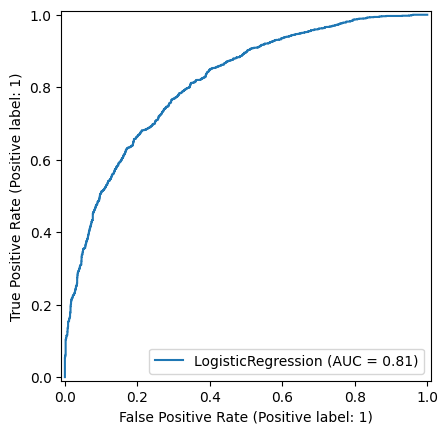

In [67]:
fig = plt.figure()
ax = fig.gca()
RocCurveDisplay.from_estimator(model_lr, X_test, y_test, ax=ax)

## 7-3 중요한 feature 고르기
- XGBClassifier 를 사용하여 승패에 가장 중요한 가장 큰 영향을 끼친 feature 하나를 찾아내세요

In [68]:
from xgboost import XGBClassifier

In [69]:
model_xgb = XGBClassifier()
model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [70]:
model_xgb.feature_importances_

array([0.02510191, 0.0246698 , 0.02823661, 0.02869373, 0.02876465,
       0.03396531, 0.02521414, 0.03058143, 0.02946877, 0.03030336,
       0.02770249, 0.02854351, 0.22107595, 0.04199795, 0.        ,
       0.        , 0.02810658, 0.02955643, 0.02711246, 0.03769168,
       0.00919579, 0.02810738, 0.02811058, 0.02513596, 0.        ,
       0.02782114, 0.02732326, 0.03913873, 0.02778825, 0.03374451,
       0.0268477 ], dtype=float32)

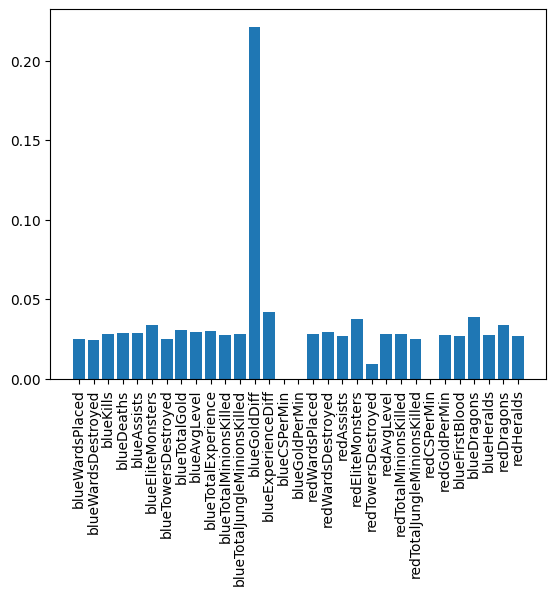

In [71]:
plt.bar(X.columns, model_xgb.feature_importances_)
plt.xticks(rotation=90)
plt.show()